In [2]:
import pandas as pd
import json


# =========================================
# 1. CSV 파일 불러오기
# =========================================

df = pd.read_csv(
    "../geo_raw_data_table.csv",
    encoding="utf-8"
)

print("전체 페이지 수 :", len(df))


# =========================================
# 2. 확인할 JSON-LD 태그
# =========================================

target_tags = [
    "material",
    "color",
    "size",
    "category",
    "sameAs",
    "shippingDetails",
    "hasMerchantReturnPolicy"
]


# =========================================
# 3. JSON 내부의 dict를 모두 찾는 함수
# =========================================

def get_all_dicts(data):

    result = []

    # 확인해야 할 데이터를 리스트에 저장
    check_list = [data]

    while len(check_list) > 0:

        # 리스트의 마지막 데이터를 꺼냄
        temp = check_list.pop()

        # dict인 경우
        if type(temp) == dict:

            result.append(temp)

            # dict 안의 값들을 다시 확인 리스트에 추가
            for key in temp:
                check_list.append(temp[key])

        # list인 경우
        elif type(temp) == list:

            for item in temp:
                check_list.append(item)

    return result


# =========================================
# 4. 태그의 값이 비어있는지 확인
# =========================================

def has_value(value):

    # None
    if value is None:
        return False

    # 빈 문자열
    if type(value) == str:
        if value.strip() == "":
            return False

    # 빈 리스트
    if type(value) == list:
        if len(value) == 0:
            return False

    # 빈 딕셔너리
    if type(value) == dict:
        if len(value) == 0:
            return False

    return True


# =========================================
# 5. Product / ProductGroup 확인
# =========================================

def is_product(data):

    if "@type" not in data:
        return False

    type_data = data["@type"]

    # @type이 문자열인 경우
    if type(type_data) == str:

        if type_data == "Product":
            return True

        if type_data == "ProductGroup":
            return True

    # @type이 리스트인 경우
    elif type(type_data) == list:

        for item in type_data:

            if item == "Product":
                return True

            if item == "ProductGroup":
                return True

    return False


# =========================================
# 6. 특정 태그가 존재하는지 확인
# =========================================

def has_tag(data, tag):

    if data is None:
        return False

    all_dicts = get_all_dicts(data)

    for item in all_dicts:

        if tag in item:

            if has_value(item[tag]):
                return True

    return False


# =========================================
# 7. 한 페이지의 description 평균 계산
# =========================================

def get_description_average(data):

    if data is None:
        return None

    all_dicts = get_all_dicts(data)

    descriptions = []

    for item in all_dicts:

        # Product와 ProductGroup을 분리하지 않고
        # 둘 다 description 대상으로 사용
        if is_product(item):

            if "description" in item:

                description = item["description"]

                if type(description) == str:

                    description = description.strip()

                    # 빈 description 제외
                    if description != "":

                        # 같은 description이 이미 있다면 중복 제외
                        if description not in descriptions:
                            descriptions.append(description)

    # description이 없는 경우
    if len(descriptions) == 0:
        return None

    # description 글자 수 합계
    total_length = 0

    for description in descriptions:
        total_length += len(description)

    # 한 페이지에 여러 description이 있으면 평균
    average = total_length / len(descriptions)

    return average


# =========================================
# 8. JSON-LD 파싱
# =========================================

json_data_list = []


for i in range(len(df)):

    raw_data = df.loc[i, "json_ld_contents"]

    # 결측치
    if pd.isna(raw_data):

        json_data_list.append(None)

    # 빈 문자열
    elif str(raw_data).strip() == "":

        json_data_list.append(None)

    else:

        # JSON 문자열 -> dict/list
        json_data = json.loads(raw_data)

        json_data_list.append(json_data)


# =========================================
# 9. 브랜드 목록 만들기
# =========================================

brand_list = []


for i in range(len(df)):

    brand = df.loc[i, "brand_name"]

    if brand not in brand_list:
        brand_list.append(brand)


print("브랜드 수 :", len(brand_list))


# =========================================
# 10. 브랜드별 분석
# =========================================

result_list = []


for brand in brand_list:

    # 페이지 수
    page_count = 0

    # JSON-LD 보유 페이지 수
    json_count = 0

    # description
    description_count = 0
    description_sum = 0

    # 태그별 카운트
    tag_count = {}

    for tag in target_tags:
        tag_count[tag] = 0


    # 전체 데이터 반복
    for i in range(len(df)):

        # 현재 브랜드가 아니면 건너뛰기
        if df.loc[i, "brand_name"] != brand:
            continue


        page_count += 1

        data = json_data_list[i]


        # -----------------------------
        # JSON-LD 보유 페이지
        # -----------------------------

        if data is not None:
            json_count += 1


        # -----------------------------
        # description
        # -----------------------------

        description_average = get_description_average(
            data
        )

        if description_average is not None:

            description_count += 1

            description_sum += description_average


        # -----------------------------
        # JSON-LD 태그
        # -----------------------------

        for tag in target_tags:

            if has_tag(data, tag):

                tag_count[tag] += 1


    # =================================
    # description 브랜드 평균
    # =================================

    brand_description_average = None

    if description_count > 0:

        brand_description_average = (
            description_sum
            / description_count
        )

        brand_description_average = round(
            brand_description_average,
            1
        )


    # =================================
    # 결과 저장
    # =================================

    result_list.append([

        brand,

        page_count,

        json_count,

        description_count,

        brand_description_average,

        tag_count["material"],

        tag_count["color"],

        tag_count["size"],

        tag_count["category"],

        tag_count["sameAs"],

        tag_count["shippingDetails"],

        tag_count["hasMerchantReturnPolicy"]
    ])


# =========================================
# 11. DataFrame으로 변환
# =========================================

columns = [

    "브랜드",

    "페이지 수",

    "JSON-LD 보유 페이지 수",

    "description 보유 페이지 수",

    "description 평균 글자 수",

    "material 보유 페이지 수",

    "color 보유 페이지 수",

    "size 보유 페이지 수",

    "category 보유 페이지 수",

    "sameAs 보유 페이지 수",

    "shippingDetails 보유 페이지 수",

    "hasMerchantReturnPolicy 보유 페이지 수"
]


result_df = pd.DataFrame(
    result_list,
    columns=columns
)


# =========================================
# 12. 결과 확인
# =========================================

result_df

전체 페이지 수 : 8763
브랜드 수 : 20


,브랜드,페이지 수,JSON-LD 보유 페이지 수,description 보유 페이지 수,description 평균 글자 수,material 보유 페이지 수,color 보유 페이지 수,size 보유 페이지 수,category 보유 페이지 수,sameAs 보유 페이지 수,shippingDetails 보유 페이지 수,hasMerchantReturnPolicy 보유 페이지 수
0,CJ,2794,2794,2794,58.6,0,0,0,2794,0,0,0
1,홀리,181,181,19,25.4,0,0,0,0,0,0,0
2,후브스,80,80,0,NaN,0,0,0,0,0,0,0
3,아이딜릭마켓,590,590,0,NaN,0,0,0,0,0,0,0
4,아일랜드모던,215,215,0,NaN,0,0,0,0,0,0,0
5,자스민벨,280,280,1,154.0,0,0,0,0,0,0,0
6,르아르,97,97,0,NaN,0,0,0,0,0,0,0
7,루프온,282,282,4,12.0,0,0,0,0,0,0,0
8,미니포에,100,100,2,47.0,0,0,0,0,0,0,0
9,보통의날,100,100,100,48.4,0,0,0,0,0,0,0


In [3]:
result_df.to_csv(
    "브랜드별_JSON-LD_분석결과.csv",
    index=False,
    encoding="utf-8-sig"
)

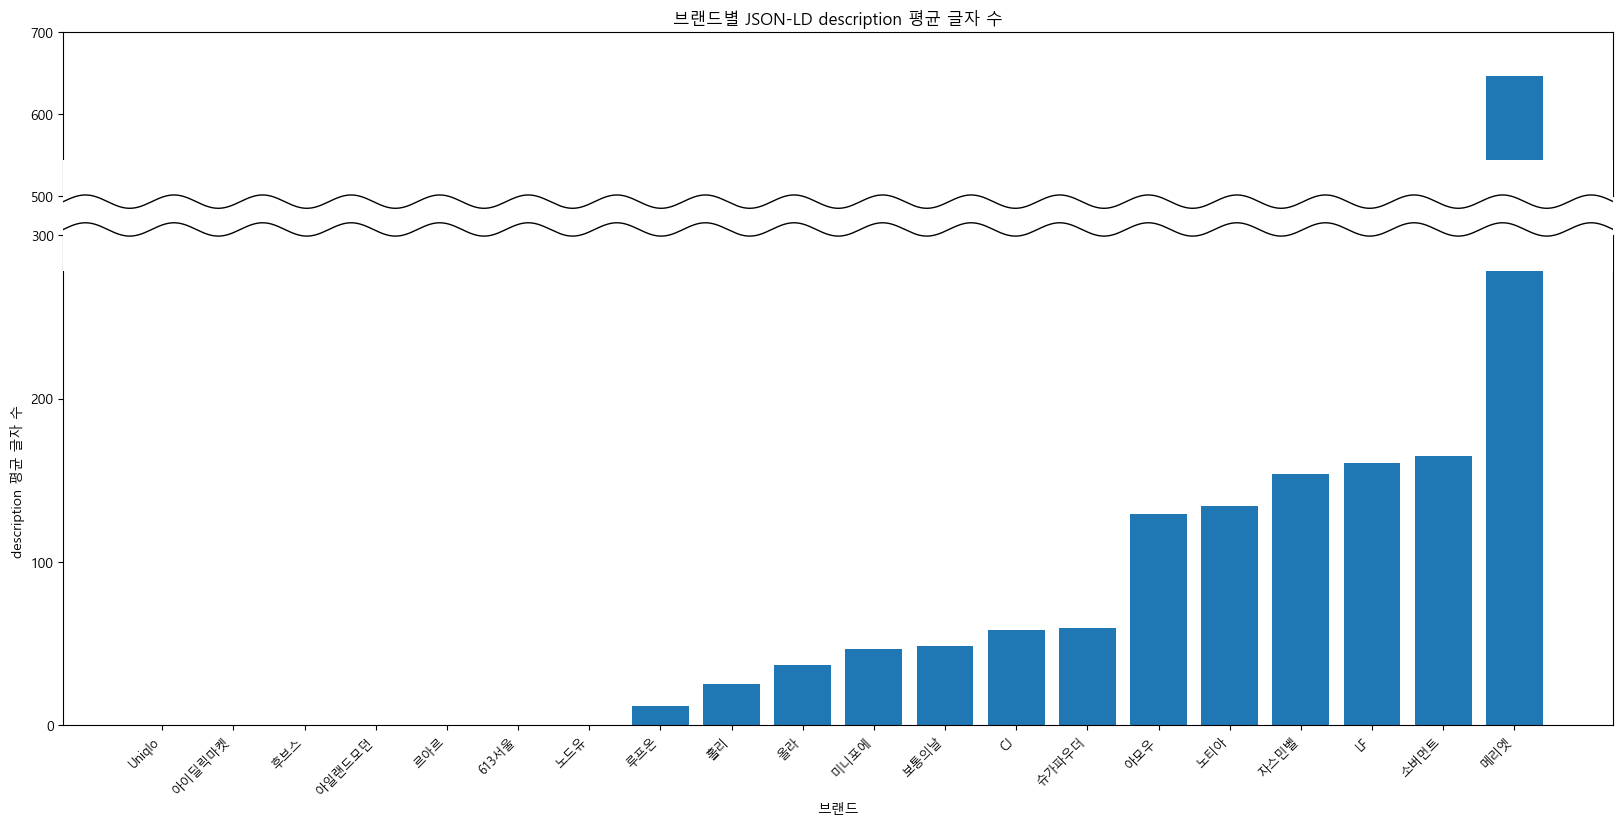

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform


# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')


# 그래프에 사용할 데이터
graph_df = result_df[
    ['브랜드', 'description 평균 글자 수']
].copy()


# description 평균이 없는 브랜드는 0으로 변경
graph_df['description 평균 글자 수'] = (
    graph_df['description 평균 글자 수'].fillna(0)
)


# description 평균이 0인 브랜드
zero_df = graph_df[
    graph_df['description 평균 글자 수'] == 0
].copy()


# description 평균이 0보다 큰 브랜드
value_df = graph_df[
    graph_df['description 평균 글자 수'] > 0
].copy()


# 0인 브랜드 순서 설정
zero_order = [
    'Uniqlo',
    '아이딜릭마켓',
    '후브스',
    '아일랜드모던',
    '르아르',
    '613서울',
    '노드유'
]


# 0인 브랜드 순서값 생성
zero_df['순서'] = 0

for i in range(len(zero_order)):
    zero_df.loc[
        zero_df['브랜드'] == zero_order[i],
        '순서'
    ] = i


# 0인 브랜드 순서 변경
zero_df = zero_df.sort_values('순서')


# 0보다 큰 브랜드는 평균 글자 수 기준 오름차순 정렬
value_df = value_df.sort_values(
    'description 평균 글자 수',
    ascending=True
)


# 두 데이터 합치기
graph_df = pd.concat([zero_df, value_df])


# x축, y축 데이터
x = graph_df['브랜드']
y = graph_df['description 평균 글자 수']


# 그래프 영역 설정
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(20, 9),
    gridspec_kw={
        'height_ratios': [1, 3]
    }
)


# 막대 그래프
ax1.bar(x, y)
ax2.bar(x, y)


# y축 범위 설정
ax1.set_ylim(500, 700)
ax2.set_ylim(0, 300)


# y축 눈금 설정
ax1.set_yticks([500, 600, 700])
ax2.set_yticks([0, 100, 200, 300])


# 중간 축 선 제거
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)


# 위쪽 그래프 x축 표시 제거
ax1.tick_params(
    axis='x',
    bottom=False,
    labelbottom=False
)


# 아래쪽 브랜드명 설정
ax2.tick_params(
    axis='x',
    labelrotation=45,
    labelsize=9
)


# 브랜드명 오른쪽 정렬
for label in ax2.get_xticklabels():
    label.set_ha('right')


# 그래프 사이 간격 설정
plt.subplots_adjust(hspace=0.12)


# 그래프 위치 확인
position1 = ax1.get_position()
position2 = ax2.get_position()


# 물결 표시 위치 계산
wave_bottom = position2.y1 - 0.04

wave_height = (
    position1.y0
    - position2.y1
    + 0.08
)


# 물결 표시용 영역 생성
wave_ax = fig.add_axes([
    position2.x0,
    wave_bottom,
    position2.width,
    wave_height
])


# 물결 영역 설정
wave_ax.set_xlim(0, 1)
wave_ax.set_ylim(-1, 1)

wave_ax.set_xticks([])
wave_ax.set_yticks([])


# 물결 영역 테두리 제거
for spine in wave_ax.spines.values():
    spine.set_visible(False)


# 물결선 데이터 생성
wave_x = np.linspace(0, 1, 500)

wave1 = (
    0.25
    + 0.12 * np.sin(
        wave_x * 35 * np.pi
    )
)

wave2 = (
    -0.25
    + 0.12 * np.sin(
        wave_x * 35 * np.pi
    )
)


# 물결선 그리기
wave_ax.plot(
    wave_x,
    wave1,
    color='black',
    linewidth=1
)

wave_ax.plot(
    wave_x,
    wave2,
    color='black',
    linewidth=1
)


# 그래프 제목
ax1.set_title(
    '브랜드별 JSON-LD description 평균 글자 수'
)


# x축, y축 이름
ax2.set_xlabel('브랜드')
ax2.set_ylabel('description 평균 글자 수')


# 그래프 출력
plt.show()